In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_performance_interactions (1).csv to student_performance_interactions (1).csv



🔍 Finding Best K:

K=2, Silhouette=0.274
K=3, Silhouette=0.198
K=4, Silhouette=0.158
K=5, Silhouette=0.157
K=6, Silhouette=0.168
K=7, Silhouette=0.166
K=8, Silhouette=0.157
K=9, Silhouette=0.158

✅ Best K Selected: 2

🔍 DBSCAN Tuning:

eps=0.5, clusters=0
eps=1.0, clusters=22

🔹 K-Means Performance:
Silhouette Score: 0.27421572973353575
Davies-Bouldin Index: 1.4088727917865673
Calinski-Harabasz Score: 473.09722892575525

🔹 Hierarchical Clustering Performance:
Silhouette Score: 0.2435350341280122
Davies-Bouldin Index: 1.5159472829864153
Calinski-Harabasz Score: 404.9829556805552

🔹 DBSCAN Performance:
Silhouette Score: 0.3476086866889439
Davies-Bouldin Index: 0.8764549987564877
Calinski-Harabasz Score: 58.188259659254925


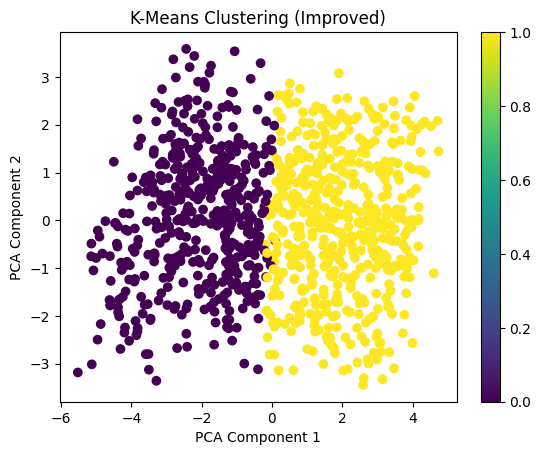

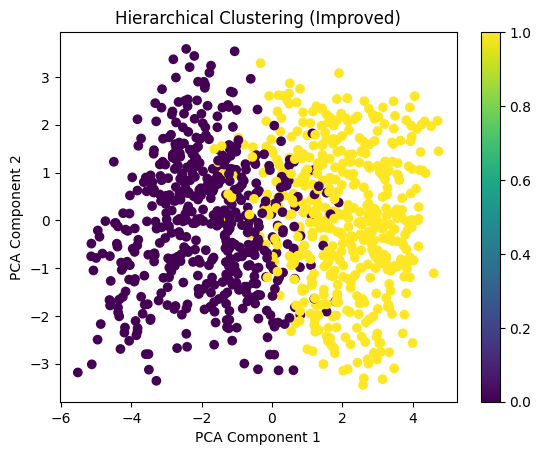

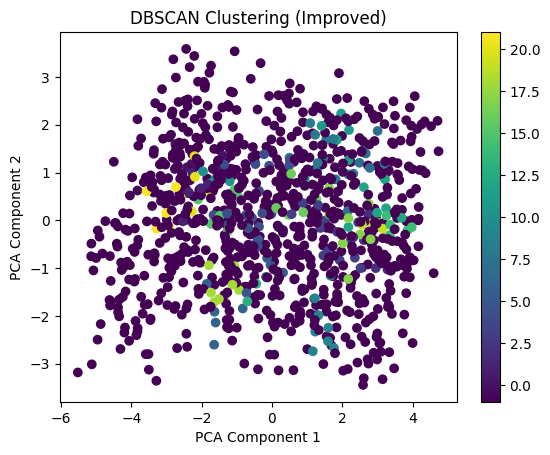

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("student_performance_interactions (1).csv")

# Drop unnecessary columns
if "student_id" in df.columns:
    df = df.drop("student_id", axis=1)

# Remove target column
if "grade" in df.columns:
    df = df.drop("grade", axis=1)

# =========================
# 2. HANDLE CATEGORICAL DATA
# =========================
df = pd.get_dummies(df, drop_first=True)

# =========================
# 3. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# =========================
# 4. PCA (DIMENSION REDUCTION)
# =========================
pca = PCA(n_components=5)
X_reduced = pca.fit_transform(X_scaled)

# =========================
# 5. FIND BEST K (K-MEANS)
# =========================
print("\n🔍 Finding Best K:\n")
best_k = 2
best_score = -1

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    print(f"K={k}, Silhouette={score:.3f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\n✅ Best K Selected: {best_k}")

# =========================
# 6. FINAL K-MEANS
# =========================
kmeans = KMeans(n_clusters=best_k, random_state=42)
k_labels = kmeans.fit_predict(X_reduced)

# =========================
# 7. HIERARCHICAL
# =========================
hier = AgglomerativeClustering(n_clusters=best_k)
h_labels = hier.fit_predict(X_reduced)

# =========================
# 8. DBSCAN TUNING
# =========================
print("\n🔍 DBSCAN Tuning:\n")

best_eps = None
best_db_labels = None

for eps in [0.5, 1.0, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_reduced)

    unique_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    print(f"eps={eps}, clusters={unique_clusters}")

    if unique_clusters > 1:
        best_eps = eps
        best_db_labels = labels
        break

# =========================
# 9. EVALUATION FUNCTION
# =========================
def evaluate_model(X, labels, name):
    if labels is None:
        print(f"\n{name}: No valid clusters found")
        return

    if -1 in labels:
        mask = labels != -1
        X_eval = X[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X
        labels_eval = labels

    if len(set(labels_eval)) > 1:
        print(f"\n🔹 {name} Performance:")
        print("Silhouette Score:", silhouette_score(X_eval, labels_eval))
        print("Davies-Bouldin Index:", davies_bouldin_score(X_eval, labels_eval))
        print("Calinski-Harabasz Score:", calinski_harabasz_score(X_eval, labels_eval))
    else:
        print(f"\n{name}: Not enough clusters")

# =========================
# 10. EVALUATE ALL MODELS
# =========================
evaluate_model(X_reduced, k_labels, "K-Means")
evaluate_model(X_reduced, h_labels, "Hierarchical Clustering")
evaluate_model(X_reduced, best_db_labels, "DBSCAN")

# =========================
# 11. PCA FOR VISUALIZATION (2D)
# =========================
pca_2d = PCA(n_components=2)
X_vis = pca_2d.fit_transform(X_scaled)

# =========================
# 12. PLOT FUNCTION
# =========================
def plot_clusters(X, labels, title):
    if labels is None:
        print(f"{title}: No clusters to display")
        return

    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar()
    plt.show()

# =========================
# 13. VISUALIZATION
# =========================
plot_clusters(X_vis, k_labels, "K-Means Clustering (Improved)")
plot_clusters(X_vis, h_labels, "Hierarchical Clustering (Improved)")
plot_clusters(X_vis, best_db_labels, "DBSCAN Clustering (Improved)")